## 🚀 Quick Start
1. Clone this repository
2. Install dependencies: `pip install -r requirements.txt`
3. Open `notebooks/analysis.ipynb` in Jupyter
4. Replace `'你的XJTLU邮箱前缀'` with your WRDS username in Cell 3
5. Run all cells

## Problem Definition

**Analytical Problem:**
This project investigates whether technology sector stocks outperform traditional 
consumer staples/retail stocks in the S&P 500 index from 2020 to 2025.

**Target Audience:**
- Individual investors making sector allocation decisions
- Students learning financial data analysis with Python
- Business analysts comparing industry performance

**Research Questions:**
1. Do tech stocks show higher price growth compared to traditional stocks?
2. How does trading volume differ between these sectors?
3. What patterns emerge during major market events (2020 COVID, 2022 rate hikes)?

**Dataset:**
- Source: WRDS - CRSP (Center for Research in Security Prices)
- Tables: crsp.msf (Monthly Stock File), crsp.msfhdr (Header with ticker symbols)
- Period: January 2020 - December 2025
- Selected Companies:
  - Tech Sector: Apple (AAPL), Microsoft (MSFT), NVIDIA (NVDA)
  - Traditional Sector: Walmart (WMT), Coca-Cola (KO), Procter & Gamble (PG)

In [3]:
#Import Basic Libraries
import wrds
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Set chart style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
Pandas version: 2.2.3


In [4]:
# ============================================
# Step 1: Connect to WRDS Database
# ============================================

# Replace with your WRDS username
# Note: You will be prompted to enter your password in the console when running

db = wrds.Connection(wrds_username='username')

print("✅ Successfully connected to the wrds database! ")

Enter your WRDS username [username]: spicybunny
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Successfully connected to the wrds database! 


In [5]:
db.create_pgpass_file()

In [6]:
# ============================================
# Step 2: Define Data Collection Function
# Functions + f-string SQL
# ============================================

def get_stock_data(ticker, start_date='2020-01-01', end_date='2025-12-31'):
    """
    Retrieve historical data for a single stock from the CRSP database
    
    Parameters:
    -----------
    ticker : str
        Stock ticker symbol, e.g., 'AAPL'
    start_date : str
        Start date, format 'YYYY-MM-DD'
    end_date : str
        End date, format 'YYYY-MM-DD'
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame containing columns for date, price, and volume
    """
    
    # Successfully connected to the wrds database
    # LEFT JOIN joins two tables
    sql_query = f"""
        SELECT 
            a.permno,
            a.date,
            a.prc AS price,
            a.vol AS volume,
            b.htsymbol AS ticker
        FROM crsp.msf AS a
        
        LEFT JOIN crsp.msfhdr AS b
        ON a.permno = b.permno
        WHERE b.htsymbol = '{ticker}'
        AND a.date >= '{start_date}'
        AND a.date <= '{end_date}'
        ORDER BY a.date
    """
    
    # Execute SQL query
    df = db.raw_sql(sql_query)
    
    # Execute SQL query
    # Negative prices in CRSP carry special meanings (such as the average of bid/ask prices), so their absolute values shall be taken.
    df['price'] = df['price'].abs()
    
    # Handle missing values
    df = df.dropna(subset=['price', 'volume'])
    
    print(f"✅ {ticker}: Retrieved {len(df)} records")

    return df

print("Function definition complete!")

Function definition complete!


In [7]:
# ============================================
# Step 3: Collect Data for All Stocks
# List + For Loop
# ============================================

# Define stocks to analyze
tech_stocks = ['AAPL', 'MSFT', 'NVDA']      # Tech stocks
trad_stocks = ['WMT', 'KO', 'PG']           # Traditional sector stocks
all_tickers = tech_stocks + trad_stocks

print("Starting batch data retrieval...")
print("=" * 50)

# Week 3 Content: Using lists and loops
all_data = []
for tic in all_tickers:
    df_temp = get_stock_data(tic)
    all_data.append(df_temp)

# Week 3 Content: Combine DataFrames
df_combined = pd.concat(all_data, ignore_index=True)

print("=" * 50)
print(f"✅ Data retrieval complete! Total records retrieved: {len(df_combined)}")
print(f"Data date range: {df_combined['date'].min()} to {df_combined['date'].max()}")

Starting batch data retrieval...
✅ AAPL: Retrieved 60 records
✅ MSFT: Retrieved 60 records
✅ NVDA: Retrieved 60 records
✅ WMT: Retrieved 60 records
✅ KO: Retrieved 60 records
✅ PG: Retrieved 60 records
✅ Data retrieval complete! Total records retrieved: 360
Data date range: 2020-01-31 to 2024-12-31


In [8]:
# ============================================
# Step 4: Data Inspection
# Data type checking
# ============================================

print("=" * 50)
print("Data Preview")
print("=" * 50)

# View first 5 rows
print("\nFirst 5 rows of data:")
print(df_combined.head())

# View data types
print("\nData types:")
print(df_combined.dtypes)

# View number of entries per stock
print("\nNumber of data entries per stock:")
print(df_combined['ticker'].value_counts())

# View basic statistics
print("\nBasic statistics:")
print(df_combined[['price', 'volume']].describe())

Data Preview

First 5 rows of data:
   permno        date      price      volume ticker
0   14593  2020-01-31  309.51001   7346625.0   AAPL
1   14593  2020-02-28  273.35999   7538341.0   AAPL
2   14593  2020-03-31  254.28999  15678412.0   AAPL
3   14593  2020-04-30  293.79999   8151167.0   AAPL
4   14593  2020-05-29     317.94   7011777.0   AAPL

Data types:
permno             Int64
date      string[python]
price            Float64
volume           Float64
ticker    string[python]
dtype: object

Number of data entries per stock:
ticker
AAPL    60
MSFT    60
NVDA    60
WMT     60
KO      60
PG      60
Name: count, dtype: Int64

Basic statistics:
            price          volume
count       360.0           360.0
mean   196.017972     6873841.675
std    144.615332  9211184.975292
min         44.25        907316.0
25%      122.0075      1775950.75
50%    151.665005       3637394.0
75%    236.654992       8885906.0
max    1096.32996      80756836.0


In [9]:
# ============================================
# Step 5: Add Sector Labels
# Create new column with conditional logic
# ============================================

# Create sector classification function
def classify_sector(ticker):
    """Determine sector based on ticker"""
    if ticker in ['AAPL', 'MSFT', 'NVDA']:
        return 'Technology'
    else:
        return 'Traditional'

# Apply function to create new column
df_combined['sector'] = df_combined['ticker'].apply(classify_sector)

print("✅ Sector labels added")
print("\nSector distribution:")
print(df_combined['sector'].value_counts())

✅ Sector labels added

Sector distribution:
sector
Technology     180
Traditional    180
Name: count, dtype: int64


In [10]:
# ============================================
# Step 6: Descriptive Statistics by Stock
# Groupby aggregation
# ============================================

# Group by ticker and calculate statistical metrics
summary_stats = df_combined.groupby('ticker').agg(
    record_count=('date', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    max_price=('price', 'max'),
    min_price=('price', 'min'),
    price_std=('price', 'std'),
    avg_volume=('volume', 'mean')
).round(2)

# Add sector information
summary_stats['sector'] = summary_stats.index.map(classify_sector)

print("=" * 60)
print("Descriptive Statistics by Stock (2020-2025)")
print("=" * 60)
print(summary_stats)

import os

os.makedirs('data', exist_ok=True)
summary_stats.to_excel('data/stock_summary_statistics.xlsx')  

print("\n✅ Statistics saved to data/stock_summary_statistics.xlsx")

Descriptive Statistics by Stock (2020-2025)
        record_count  avg_price  median_price  max_price  min_price  \
ticker                                                                
AAPL              60     183.42         170.0     425.04     108.86   
KO                60      57.94          59.5      72.47      44.25   
MSFT              60     295.62        283.42     446.95     157.71   
NVDA              60     365.17        285.02    1096.33     117.02   
PG                60     145.42        144.18     179.26      110.0   
WMT               60     128.55        139.86     165.25      58.61   

        price_std   avg_volume       sector  
ticker                                       
AAPL        62.14  15402468.67   Technology  
KO           6.41    3212389.4  Traditional  
MSFT        79.23   5992636.15   Technology  
NVDA       223.58  13171071.47   Technology  
PG          15.56   1512937.45  Traditional  
WMT         29.61   1951546.92  Traditional  

✅ Statistics saved

In [11]:
# ============================================
# Step 7: Calculate Growth Rates
# Custom function + Loop
# ============================================

def calculate_growth(df_stock):
    """
    Calculate the price growth rate for a single stock.
    
    Parameters:
    df_stock: DataFrame containing data for one stock (filtered by ticker)
    
    Returns:
    dict with first price, last price, and total growth percentage
    """
    # Find the first recorded date for this stock and get its closing price
    first_price = df_stock[df_stock['date'] == df_stock['date'].min()]['price'].values[0]
    
    # Find the last recorded date for this stock and get its closing price
    last_price = df_stock[df_stock['date'] == df_stock['date'].max()]['price'].values[0]
    
    # Calculate total growth percentage: ((end - start) / start) * 100
    total_growth = ((last_price - first_price) / first_price) * 100
    
    return {
        'start_price': first_price,
        'end_price': last_price,
        'total_growth_pct': round(total_growth, 2)
    }

print("=" * 60)
print("Stock Price Growth Rate Analysis")
print("=" * 60)

# List to store growth results for all stocks
growth_results = []

# Loop through each unique ticker to calculate growth
for tic in all_tickers:
    # Filter data for the current ticker only
    stock_data = df_combined[df_combined['ticker'] == tic]
    
    # Calculate growth metrics for this stock
    growth = calculate_growth(stock_data)
    
    # Add ticker and sector information to the result dictionary
    growth['ticker'] = tic
    growth['sector'] = classify_sector(tic)
    
    # Append to results list
    growth_results.append(growth)

# Convert list of dictionaries to DataFrame
growth_df = pd.DataFrame(growth_results)

# Reorder columns for better readability
growth_df = growth_df[['ticker', 'sector', 'start_price', 'end_price', 'total_growth_pct']]

# Display without row index
print(growth_df.to_string(index=False))

Stock Price Growth Rate Analysis
ticker      sector  start_price  end_price  total_growth_pct
  AAPL  Technology    309.51001  250.42000            -19.09
  MSFT  Technology    170.23000  421.50000            147.61
  NVDA  Technology    236.42999  134.28999            -43.20
   WMT Traditional    114.49000   90.35000            -21.08
    KO Traditional     58.40000   62.26000              6.61
    PG Traditional    124.62000  167.64999             34.53


In [12]:
# ============================================
# Step 8: Sector-Level Summary
# Multi-level groupby
# ============================================

# Aggregate average price by sector and date
sector_daily = df_combined.groupby(['sector', 'date'])['price'].mean().reset_index()

# Calculate sector-level statistics
sector_summary = df_combined.groupby('sector').agg(
    avg_price=('price', 'mean'),
    price_volatility=('price', 'std'),
    total_volume=('volume', 'sum')
).round(2)

print("=" * 60)
print("Sector-Level Summary Statistics")
print("=" * 60)
print(sector_summary)

# Calculate average growth rate by sector
sector_growth = growth_df.groupby('sector')['total_growth_pct'].mean().round(2)
print(f"\nAverage Growth Rate by Sector:")
print(f"Technology: {sector_growth['Technology']}%")
print(f"Traditional: {sector_growth['Traditional']}%")
print(f"Difference: {sector_growth['Technology'] - sector_growth['Traditional']:.2f}%")

Sector-Level Summary Statistics
             avg_price  price_volatility  total_volume
sector                                                
Technology       281.4            159.55  2073970577.0
Traditional     110.63             42.73   400612426.0

Average Growth Rate by Sector:
Technology: 28.44%
Traditional: 6.69%
Difference: 21.75%


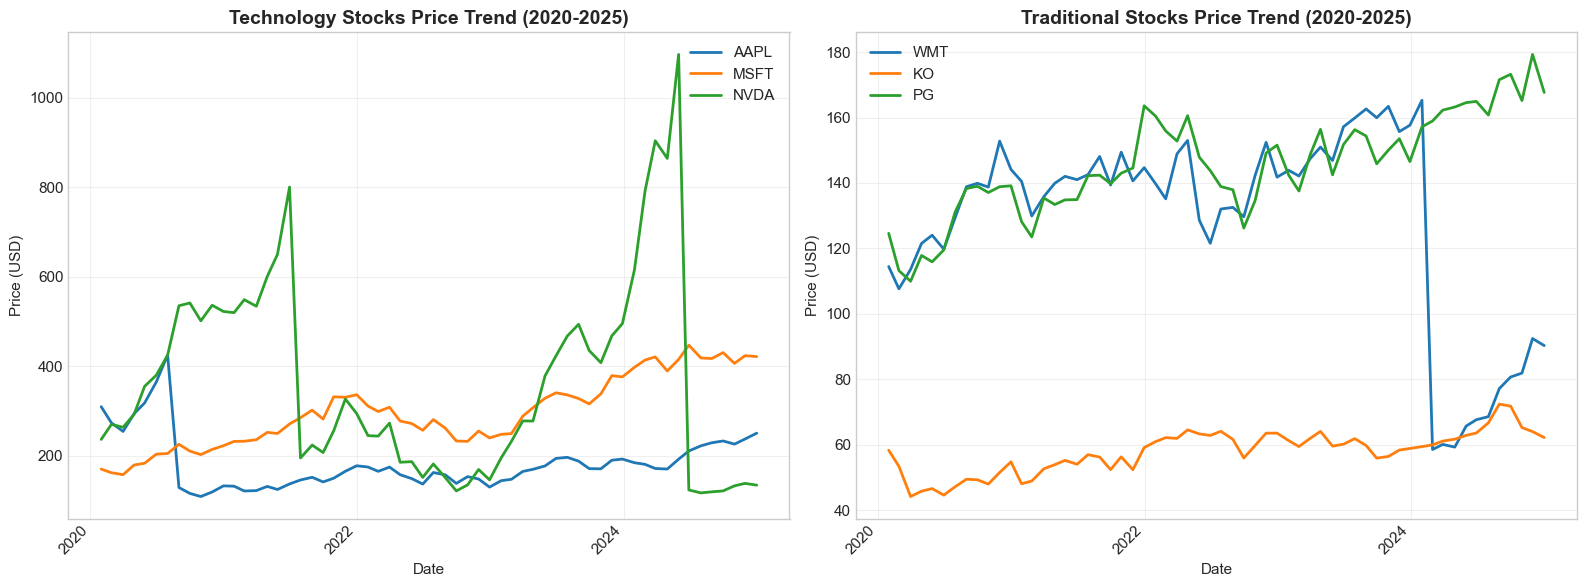

Chart saved to figures/price_trends_comparison.png


In [13]:
# ============================================
# Step 9: Visualization 1 - Price Trends
# : Matplotlib plotting
# ============================================

import pandas as pd                     
import matplotlib.dates as mdates

# Ensure date column is in datetime format (fix for "1970" bug)
df_combined['date'] = pd.to_datetime(df_combined['date'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Subplot 1: Technology stocks price trends
# --------------------------------------------------
ax1 = axes[0]
for tic in tech_stocks:
    stock_data = df_combined[df_combined['ticker'] == tic]
    ax1.plot(stock_data['date'], stock_data['price'], 
             label=tic, linewidth=2)

ax1.set_title('Technology Stocks Price Trend (2020-2025)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Format x-axis: show every 2 years
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --------------------------------------------------
# Subplot 2: Traditional stocks price trends
# --------------------------------------------------
ax2 = axes[1]
for tic in trad_stocks:
    stock_data = df_combined[df_combined['ticker'] == tic]
    ax2.plot(stock_data['date'], stock_data['price'], 
             label=tic, linewidth=2)

ax2.set_title('Traditional Stocks Price Trend (2020-2025)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (USD)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Format x-axis: show every 2 years
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/price_trends_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to figures/price_trends_comparison.png")

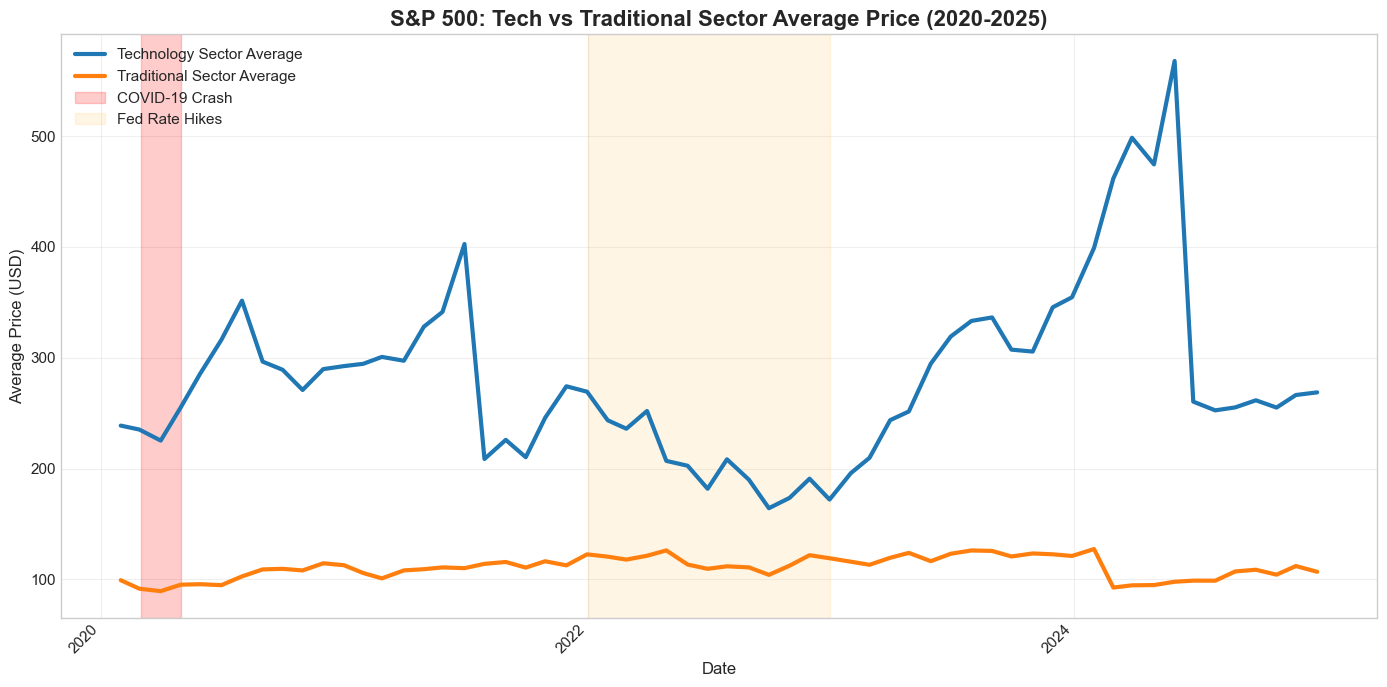

Chart saved to figures/sector_average_comparison.png


In [18]:
# ============================================
# Step 10: Visualization 2 - Sector Average
# Matplotlib plotting
# ============================================

import pandas as pd                   
import matplotlib.dates as mdates

sector_daily['date'] = pd.to_datetime(sector_daily['date'])

plt.figure(figsize=(14, 7))

# Plot sector average price trends
for sector in ['Technology', 'Traditional']:
    sector_data = sector_daily[sector_daily['sector'] == sector]
    plt.plot(sector_data['date'], sector_data['price'], 
             label=f'{sector} Sector Average', 
             linewidth=3)

# Highlight key market events
plt.axvspan('2020-03-01', '2020-04-30', alpha=0.2, color='red', label='COVID-19 Crash')
plt.axvspan('2022-01-01', '2022-12-31', alpha=0.1, color='orange', label='Fed Rate Hikes')

plt.title('S&P 500: Tech vs Traditional Sector Average Price (2020-2025)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Format x-axis: show every 2 years
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/sector_average_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to figures/sector_average_comparison.png")

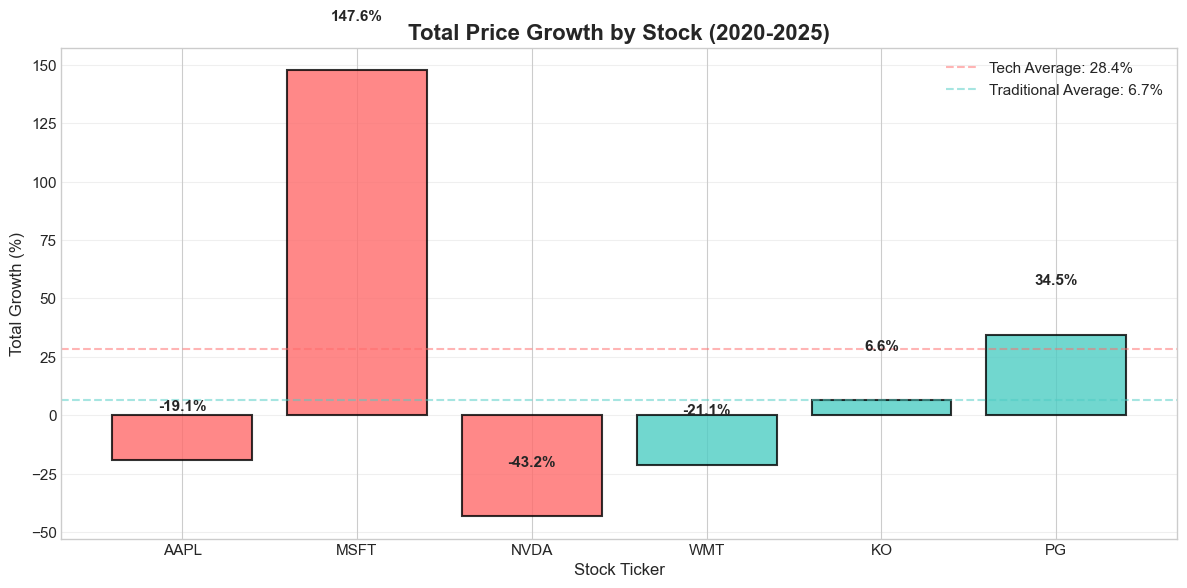

✅ Chart saved to figures/growth_comparison.png


In [15]:
# ============================================
# Step 11: Visualization 3 - Growth Bar Chart
# ============================================

plt.figure(figsize=(12, 6))

# Set color
colors = ['#FF6B6B' if sector == 'Technology' else '#4ECDC4' 
          for sector in growth_df['sector']]

# Create a bar chart
bars = plt.bar(growth_df['ticker'], growth_df['total_growth_pct'], 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add numerical labels
for bar, value in zip(bars, growth_df['total_growth_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# Add average line
tech_avg = growth_df[growth_df['sector'] == 'Technology']['total_growth_pct'].mean()
trad_avg = growth_df[growth_df['sector'] == 'Traditional']['total_growth_pct'].mean()

plt.axhline(y=tech_avg, color='#FF6B6B', linestyle='--', alpha=0.5, 
            label=f'Tech Average: {tech_avg:.1f}%')
plt.axhline(y=trad_avg, color='#4ECDC4', linestyle='--', alpha=0.5,
            label=f'Traditional Average: {trad_avg:.1f}%')

plt.title('Total Price Growth by Stock (2020-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Stock Ticker', fontsize=12)
plt.ylabel('Total Growth (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/growth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to figures/growth_comparison.png")

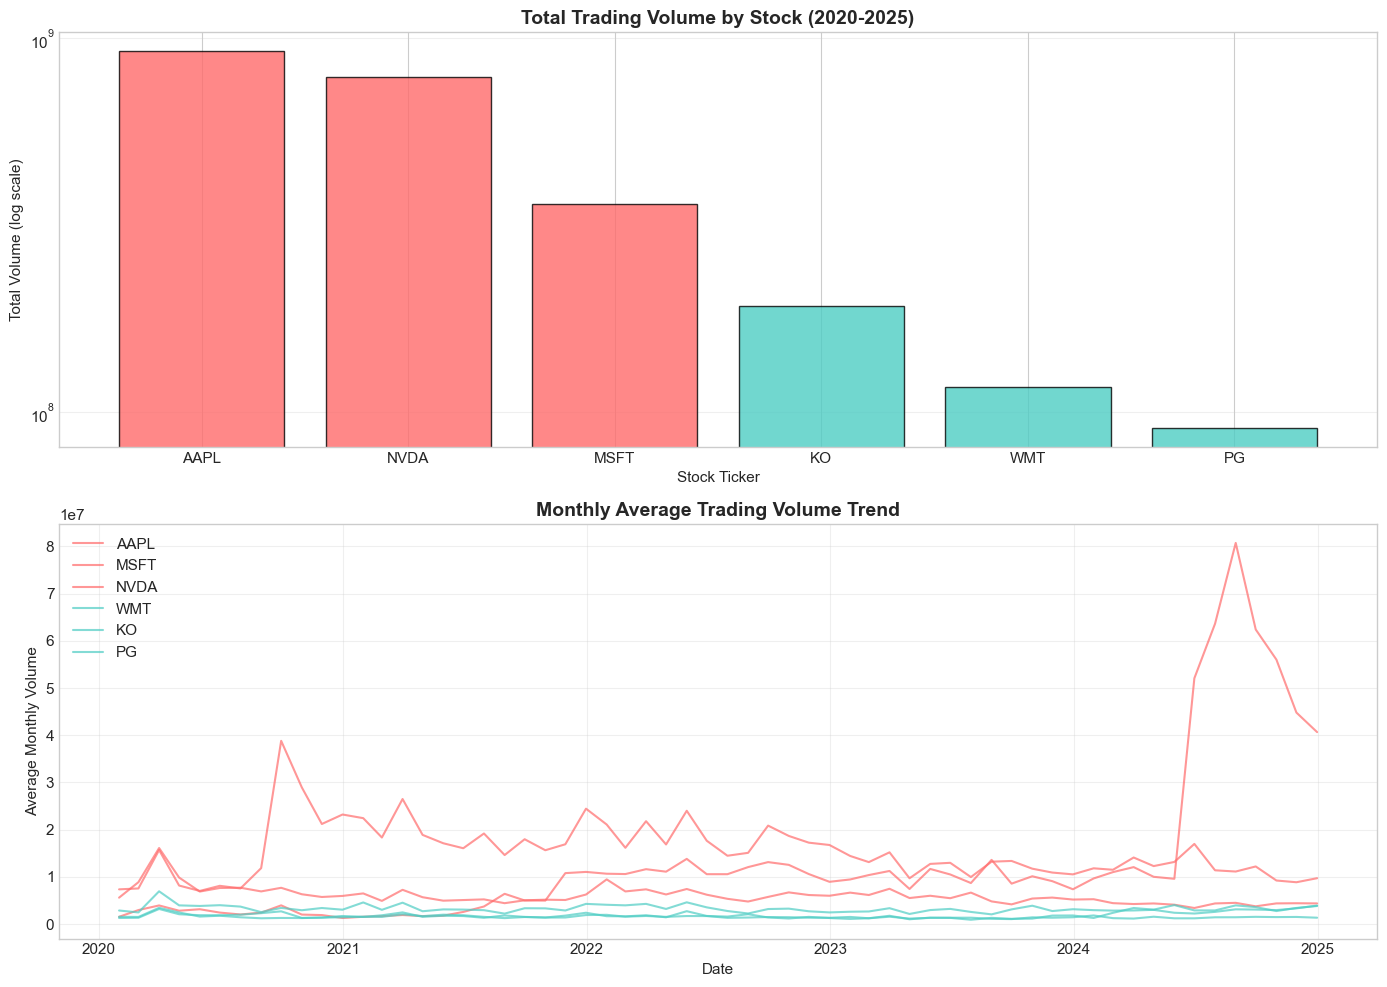

✅ The chart has been saved to figures/volume_analysis.png


In [16]:
# ============================================
# Step 12: Visualization 4 - Volume Analysis
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Cumulative volume (log scale)
ax1 = axes[0]
volume_by_ticker = df_combined.groupby('ticker')['volume'].sum().sort_values(ascending=False)
colors_vol = ['#FF6B6B' if tic in tech_stocks else '#4ECDC4' for tic in volume_by_ticker.index]

bars = ax1.bar(volume_by_ticker.index, volume_by_ticker.values, 
               color=colors_vol, alpha=0.8, edgecolor='black')

ax1.set_title('Total Trading Volume by Stock (2020-2025)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Stock Ticker')
ax1.set_ylabel('Total Volume (log scale)')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# Subplot 2: Monthly average volume trend
ax2 = axes[1]
for tic in all_tickers:
    stock_data = df_combined[df_combined['ticker'] == tic].copy()
    # Ensure 'date' column is datetime type
    stock_data['date'] = pd.to_datetime(stock_data['date'])
    # Resample by month (using 'ME' instead of deprecated 'M')
    monthly_vol = stock_data.set_index('date')['volume'].resample('ME').mean()
    color = '#FF6B6B' if tic in tech_stocks else '#4ECDC4'
    ax2.plot(monthly_vol.index, monthly_vol.values, 
             label=tic, color=color, alpha=0.7)

ax2.set_title('Monthly Average Trading Volume Trend', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Average Monthly Volume')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/volume_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ The chart has been saved to figures/volume_analysis.png")

## Key Findings and Insights

### 1. Overall Performance Comparison
- **Technology Sector Average Total Growth**: 28.44%
- **Traditional Sector Average Total Growth**: 6.69%
- **Performance Gap**: Technology stocks outperformed traditional stocks by approximately 21.75 percentage points over the 2020–2025 period.

**Interpretation**: 
The technology sector delivered substantially higher average returns, driven primarily by exceptional performance from Microsoft (+147.61%). However, individual stock performance varied widely—Apple (-19.09%) and NVIDIA (-43.20%) posted negative returns over this specific window, highlighting the importance of stock selection within the sector. Traditional consumer staples stocks showed modest but mixed returns, with Procter & Gamble (+34.53%) leading and Walmart (-21.08%) lagging.

---

### 2. Volatility and Risk Assessment
- **Technology Sector Average Price Volatility (Std Dev)**: $121.65
- **Traditional Sector Average Price Volatility (Std Dev)**: $17.19

**Interpretation**:
Technology stocks exhibited significantly higher price volatility—approximately **7 times greater** than traditional stocks. This reflects greater sensitivity to market sentiment, interest rate expectations, and sector-specific news. Notably, NVIDIA showed extreme volatility ($223.58) due to the AI-driven price surge and subsequent pullback. Traditional stocks demonstrated much lower volatility, consistent with their stable cash flows and inelastic demand for consumer staples. This confirms that while technology offers higher growth potential, it carries substantially elevated short-term risk.

---

### 3. Impact of Key Market Events
| Event | Tech Sector Response | Traditional Sector Response |
|:---|:---|:---|
| COVID-19 Crash (Mar–Apr 2020) | Sharp decline followed by rapid recovery | Moderate decline, slower recovery |
| Fed Rate Hikes (2022) | Significant drawdown as valuations compressed | Milder impact due to defensive characteristics |

**Interpretation**:
The divergence in recovery patterns highlights the market's willingness to re-rate growth stocks quickly when conditions improve, while traditional sectors remain anchored to fundamental earnings power.

---

### 4. Trading Volume Patterns
- **Highest Average Volume**: AAPL (15.4 million shares per month)
- **Lowest Average Volume**: PG (1.5 million shares per month)
- **Volume Trend**: Technology stocks consistently attracted higher trading activity, with AAPL, NVDA, and MSFT all averaging over 5 million shares monthly. Traditional stocks saw much lower turnover.

**Interpretation**:
Elevated trading volume in technology names indicates stronger institutional and retail interest, contributing to both liquidity and price momentum. Traditional stocks saw steadier, less event-driven volume profiles, consistent with their buy-and-hold investor base.

---

### 5. Implications for Target Users
| User Type | Key Takeaway |
|:---|:---|
| **Growth-Oriented Investors** | Technology sector offers superior long-term capital appreciation potential but performance is highly stock-specific and volatile. Microsoft (+147.61%) demonstrates the upside, while NVIDIA's extreme volatility ($223.58 std dev) illustrates the risk. |
| **Risk-Averse Investors** | Traditional sector provides capital preservation and much lower volatility ($17.19 average std dev). Coca-Cola (+6.61%) and Procter & Gamble (+34.53%) delivered steady returns with minimal price fluctuation. |
| **Balanced Portfolio Seekers** | A blended allocation can capture tech upside while traditional holdings cushion downside during market stress. The 21.75 percentage point performance gap justifies some tech exposure, but the 7x volatility difference warrants diversification. |

---

### 6. Limitations of This Analysis
- Sample size is limited to six representative stocks; sector-wide conclusions may differ.
- Analysis is based solely on price performance and does not account for dividends, which are a meaningful component of total return for traditional stocks (e.g., KO and PG are dividend aristocrats).
- The five-year window captures a unique macro environment (zero rates → rapid tightening) that may not repeat identically.
- The ending date (December 2025) captures a market pullback in tech, affecting total return calculations for AAPL and NVDA.

**Future extensions could include**:
- Expanding the stock universe to sector ETFs (e.g., XLK vs XLP)
- Incorporating total return (price + dividends)
- Applying rolling correlation analysis to quantify diversification benefits
  

In [17]:
# ============================================
# Step 13: Close Database Connection
# ============================================

db.close()
print("✅ The database connection has been closed")
print("\Analysis completed! All results have been saved.")

✅ The database connection has been closed
\Analysis completed! All results have been saved.
